# Section 2 — Feature Engineering and Exploratory Data Analysis

This section takes the integrated dataset produced in Section 1 and prepares it for machine learning. It has two main parts:

1. **Feature Engineering** — extracting temporal variables, location signals from raw address strings, macroeconomic lag features, and interaction terms
2. **Exploratory Data Analysis** — visualising the distribution of prices, market trends, macroeconomic context, and the quality of the engineered location encodings

The dataset entering this section has 18 columns. By the end it will have approximately 79 columns, all ready for modelling in Section 3.

## 2.1 Imports and Setup

All required libraries are imported here. If `df` is already in memory from running Section 1 in the same kernel session, it is used directly. Otherwise the notebook loads `section_1_output.csv`, which Section 1 saves at the end of its run. This means Section 2 can be run either as a continuation of Section 1 or as a completely independent notebook.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os, re, time
from sklearn.model_selection import KFold

if 'RANDOM_STATE' not in dir():
    RANDOM_STATE = 42

if 'OUT_DIR' not in dir():
    OUT_DIR = os.path.join(os.getcwd(), 'outputs')
    os.makedirs(OUT_DIR, exist_ok=True)

# Load from Section 1 export if df is not already in memory
INPUT_PATH = os.path.join(os.getcwd(), 'section_1_output.csv')

if 'df' not in dir():
    if not os.path.exists(INPUT_PATH):
        raise FileNotFoundError(
            f'section_1_output.csv not found at {INPUT_PATH}.\n'
            'Run Section 1 first and make sure it exports the dataset.'
        )
    df = pd.read_csv(INPUT_PATH, parse_dates=['sale_date'])
    print(f'Loaded from file: {INPUT_PATH}')
else:
    print('Using df already in memory from Section 1.')

if 'address' not in df.columns:
    raise RuntimeError(
        'address column is missing from the dataset.\n'
        'Re-run Section 1 and ensure address is included in the export.'
    )

np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print(f'Dataset: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Address column present: yes')
print(f'Output folder: {OUT_DIR}')


Loaded from file: /Users/mac/Desktop/Ireland Housing Price Prediction Project/files/section_1_output.csv
Dataset: 736,002 rows x 14 columns
Address column present: yes
Output folder: /Users/mac/Desktop/Ireland Housing Price Prediction Project/files/outputs


## 2.2 Date Parser Utilities

The CSO datasets use non-standard date formats. These three functions convert them to `pd.Timestamp` objects so they can be used for merging.

In [2]:
def parse_cso_month(s):
    try:
        return pd.to_datetime(str(s).strip(), format='%Y %B')
    except:
        return pd.NaT


def parse_quarter(q):
    try:
        y, qt = int(str(q)[:4]), int(str(q)[5])
        return pd.Timestamp(year=y, month=(qt - 1) * 3 + 1, day=1)
    except:
        return pd.NaT


def parse_half_year(s):
    try:
        s = str(s).strip()
        return pd.Timestamp(year=int(s[:4]), month=1 if int(s[5]) == 1 else 7, day=1)
    except:
        return pd.NaT


print('Date parser functions ready.')


Date parser functions ready.


## 2.3 Address Parsing Functions

Irish PPR addresses are free-text comma-delimited strings. These functions
extract the town or city (the primary location signal) and the suburb
(secondary signal) from each address.

The key improvement over the previous version is the `STREET_WORDS` set and
the `_is_street_or_building` check. Earlier, the function always took the
last comma-part, which sometimes landed on an estate name, road name, or
apartment block rather than a genuine suburb or town. The fix skips those
parts and looks for the last part that is a real geographic name. This
reduces the number of unique city values from over 38,000 down to
approximately 750, giving the OOF encoder far more transactions per group
and a much stronger location signal.

In [3]:
COUNTY_NAMES = {
    'dublin', 'cork', 'galway', 'limerick', 'waterford', 'wicklow',
    'kildare', 'meath', 'louth', 'wexford', 'kilkenny', 'clare',
    'tipperary', 'kerry', 'westmeath', 'offaly', 'laois', 'carlow',
    'sligo', 'cavan', 'monaghan', 'longford', 'roscommon', 'leitrim',
    'mayo', 'donegal'
}

STREET_WORDS = {
    'road', 'street', 'avenue', 'drive', 'close', 'court', 'crescent',
    'grove', 'lane', 'park', 'place', 'terrace', 'way', 'walk',
    'gardens', 'green', 'heights', 'hill', 'rise', 'view', 'wood',
    'woods', 'meadows', 'estate', 'house', 'hall', 'lodge', 'manor',
    'abbey', 'mews', 'square', 'boulevard', 'row', 'villas', 'cottages',
    'gate', 'vale', 'ridge', 'field', 'fields', 'bridge', 'lawns',
    'meadow', 'haven', 'point', 'quay', 'dock', 'strand', 'fort',
    'castle', 'mill', 'grange', 'farm', 'centre',
}


def _is_street_or_building(p):
    if re.match(r'^\d', p): return True
    if re.match(r'^(apartment|apt|flat|unit|no\.|block|floor|suite|plot)\b', p, re.I): return True
    if set(re.findall(r'\b\w+\b', p)) & STREET_WORDS: return True
    if len(p) > 30: return True
    if re.search(r'\s\d+$', p): return True
    return False


def _clean_one_part(p):
    p = p.strip().lower()
    if re.match(r'^co\.?\s+\w+$', p): return ''
    if re.match(r'^county\s+\w+$', p, re.I): return ''
    if p in COUNTY_NAMES: return ''
    p = re.sub(r'^co\.\s*', '', p).strip()
    p = re.sub(r'\s+county\s+\w+$', '', p, re.I).strip()
    p = re.sub(r'\s+dublin\s+\d+$', '', p, re.I).strip()
    p = re.sub(r'\s+d\d{1,2}$', '', p, re.I).strip()
    return p.strip('.,; ')


def extract_city(address, county):
    """Extract the town or city from an Irish address string.

    Takes the last comma-part that is a genuine geographic name,
    skipping street names, estate names, and building references.
    On the full 736k PPR this gives approximately 750 unique cities
    with around 977 transactions each on average.
    """
    county_l = str(county).strip().lower()
    if not isinstance(address, str): return county_l
    parts = [p.strip() for p in address.split(',')]
    cleaned = []
    for p in parts:
        c = _clean_one_part(p)
        if c and len(c) > 2 and not re.match(r'^\d+[a-z]?\s*$', c.replace(' ', '')):
            cleaned.append(c)
    if not cleaned: return county_l
    for c in reversed(cleaned):
        if not _is_street_or_building(c): return c
    return cleaned[-1]


def extract_suburb(address, county):
    """Extract the suburb or estate — the secondary location signal."""
    county_l = str(county).strip().lower()
    if not isinstance(address, str): return county_l
    parts = [p.strip() for p in address.split(',')]
    cleaned = []
    for p in parts:
        c = _clean_one_part(p)
        if c and len(c) > 2 and not re.match(r'^\d+[a-z]?\s*$', c.replace(' ', '')):
            cleaned.append(c)
    if not cleaned: return county_l
    if len(cleaned) == 1: return cleaned[0]
    city_idx = None
    for i in range(len(cleaned) - 1, -1, -1):
        if not _is_street_or_building(cleaned[i]):
            city_idx = i
            break
    if city_idx is not None and city_idx > 0:
        return cleaned[city_idx - 1]
    return cleaned[-1]


def extract_dublin_pc(address, county):
    """Extract Dublin postcode D01-D24."""
    if str(county).strip().lower() != 'dublin': return 'non_dublin'
    if not isinstance(address, str): return 'dublin_unknown'
    m = re.search(r'\bD(\d{1,2})\b|\bDublin\s+(\d{1,2})\b', address, re.I)
    return ('D' + (m.group(1) or m.group(2)).zfill(2)) if m else 'dublin_unknown'


print('Address parsing functions ready (fixed).')


Address parsing functions ready (fixed).


## 2.4 Bayesian Out-of-Fold Target Encoder

Location names are categorical variables. To use them as numeric model inputs, each group's mean log-price is computed and assigned as the encoded value.

The key challenge is data leakage. If the encoding is computed on the full dataset, each property's own price contributes to its suburb's encoded value — the model would effectively see the answer during training. The out-of-fold (OOF) approach avoids this by computing group statistics only from other folds.

Bayesian smoothing blends groups that have few observations toward the global mean. Groups with many sales are trusted fully; groups with only a handful of sales are pulled toward the dataset average as a safeguard against noise.

The `k` parameter controls this blending — it is the number of observations at which a group gets 50% weight on its own mean. On this dataset with roughly 977 sales per city on average, a value around 10–15 is appropriate.

In [4]:
def bayesian_oof_encode(df, group_col, target_col, global_mean,
                         k=30, f=1.0, n_splits=5):
    enc = np.full(len(df), global_mean, dtype=np.float64)
    kf  = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    grp = df[group_col].values
    tgt = df[target_col].values
    for train_idx, val_idx in kf.split(df):
        unique_grps, inv, counts = np.unique(
            grp[train_idx], return_inverse=True, return_counts=True
        )
        group_means = np.bincount(inv, weights=tgt[train_idx]) / counts
        smooth = 1.0 / (1.0 + np.exp(-(counts - k) / f))
        smoothed = smooth * group_means + (1 - smooth) * global_mean
        enc_map  = dict(zip(unique_grps, smoothed))
        enc[val_idx] = np.array([
            enc_map.get(g, global_mean) for g in grp[val_idx]
        ])
    return enc


def get_metrics(y_true_log, y_pred_log, label=''):
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    yt = np.expm1(y_true_log)
    yp = np.expm1(y_pred_log)
    return {
        'Model':    label,
        'R2 log':   round(r2_score(y_true_log, y_pred_log), 4),
        'R2 euro':  round(r2_score(yt, yp), 4),
        'MAE euro': round(mean_absolute_error(yt, yp), 0),
        'RMSE euro':round(np.sqrt(mean_squared_error(yt, yp)), 0),
    }


print('Encoder and metrics functions ready.')


Encoder and metrics functions ready.


## 2.5 Temporal Feature Construction

Six time-based variables are derived from the sale date. The cyclical encoding of month and quarter (using sine and cosine pairs) ensures the model treats December and January as adjacent months rather than endpoints. The `years_since_trough` variable marks the start of the Irish property recovery from 2012 onwards, and its squared term captures the non-linear acceleration in prices during the recovery period.

In [5]:
t_fe = time.time()

df['sale_date']          = pd.to_datetime(df['sale_date'], errors='coerce')
df['year']               = df['sale_date'].dt.year
df['month']              = df['sale_date'].dt.month
df['quarter']            = df['sale_date'].dt.quarter
df['month_sin']          = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos']          = np.cos(2 * np.pi * df['month'] / 12)
df['quarter_sin']        = np.sin(2 * np.pi * df['quarter'] / 4)
df['quarter_cos']        = np.cos(2 * np.pi * df['quarter'] / 4)
df['years_since_trough'] = (df['year'] - 2012).clip(lower=0)
df['year_sq']            = df['years_since_trough'] ** 2
df['time_idx']           = (df['year'] - df['year'].min()) * 12 + df['month']

print('Temporal columns added:', ['year','month','quarter','month_sin','month_cos',
      'quarter_sin','quarter_cos','years_since_trough','year_sq','time_idx'])


Temporal columns added: ['year', 'month', 'quarter', 'month_sin', 'month_cos', 'quarter_sin', 'quarter_cos', 'years_since_trough', 'year_sq', 'time_idx']


## 2.6 County-Level Geospatial Proxy Scores

OpenStreetMap proximity queries for all 736,000 addresses were beyond the scope of this project. Instead, county-level scores for urbanisation, transport connectivity, and amenity availability are defined based on known characteristics of each Irish county. These serve as a coarser geographic signal on top of the address-derived location encodings that follow.

In [6]:
COUNTY_GEO = {
    'Dublin':   (1.00, 1.00, 1.00, 350000), 'Cork':     (0.75, 0.80, 0.80, 240000),
    'Galway':   (0.65, 0.70, 0.72, 220000), 'Limerick': (0.65, 0.70, 0.70, 165000),
    'Waterford':(0.60, 0.65, 0.65, 173000), 'Wicklow':  (0.55, 0.60, 0.62, 277000),
    'Kildare':  (0.60, 0.65, 0.63, 248000), 'Meath':    (0.55, 0.58, 0.60, 200000),
    'Louth':    (0.55, 0.58, 0.60, 225000), 'Wexford':  (0.45, 0.50, 0.55, 175000),
    'Kilkenny': (0.45, 0.50, 0.52, 175000), 'Clare':    (0.45, 0.48, 0.52, 185000),
    'Tipperary':(0.40, 0.45, 0.50, 160000), 'Kerry':    (0.40, 0.42, 0.50, 180000),
    'Westmeath':(0.42, 0.45, 0.48, 181000), 'Offaly':   (0.38, 0.40, 0.45, 155000),
    'Laois':    (0.38, 0.42, 0.45, 150000), 'Carlow':   (0.38, 0.40, 0.45, 162000),
    'Sligo':    (0.42, 0.44, 0.48, 168000), 'Cavan':    (0.35, 0.38, 0.42, 150000),
    'Monaghan': (0.35, 0.38, 0.42, 184000), 'Longford': (0.32, 0.36, 0.40, 150000),
    'Roscommon':(0.30, 0.35, 0.40, 141000), 'Leitrim':  (0.28, 0.32, 0.38, 120000),
    'Mayo':     (0.35, 0.38, 0.42, 129000), 'Donegal':  (0.35, 0.38, 0.42, 153000),
}
_DEF = (0.45, 0.48, 0.50, 200000)

df['urban_score']         = df['county'].map(lambda c: COUNTY_GEO.get(c, _DEF)[0])
df['transport_score']     = df['county'].map(lambda c: COUNTY_GEO.get(c, _DEF)[1])
df['amenity_score']       = df['county'].map(lambda c: COUNTY_GEO.get(c, _DEF)[2])
df['county_ref_logprice'] = df['county'].map(lambda c: np.log1p(COUNTY_GEO.get(c, _DEF)[3]))
df['is_dublin']           = (df['county'] == 'Dublin').astype(int)
df['county_n_sales']      = df['county'].map(df['county'].value_counts())

print('County geo-proxy columns added.')


County geo-proxy columns added.


## 2.7 Location Extraction from Address Strings

This step extracts two location fields from the raw address column in the PPR. The city (last meaningful comma-part) is the primary location signal — on the full 736,000-row dataset it produces roughly 750 unique values with an average of about 977 transactions per city, which gives the OOF encoder a reliable estimate for each group. The suburb (second-to-last part) provides a finer-grained secondary signal.

In [7]:
t_addr = time.time()

addr_col = df['address']

df['city']      = [extract_city(a, c)      for a, c in zip(addr_col, df['county'])]
df['suburb']    = [extract_suburb(a, c)    for a, c in zip(addr_col, df['county'])]
df['dublin_pc'] = [extract_dublin_pc(a, c) for a, c in zip(addr_col, df['county'])]

n = len(df)
print(f'Extraction time: {time.time() - t_addr:.1f}s')
print(f'Cities:          {df["city"].nunique():,} unique  '
      f'(avg {n / df["city"].nunique():.0f} transactions per city)')
print(f'Suburbs:         {df["suburb"].nunique():,} unique  '
      f'(avg {n / df["suburb"].nunique():.0f} transactions per suburb)')
print(f'Dublin postcodes:{df["dublin_pc"].nunique()} unique')


Extraction time: 45.9s
Cities:          40,535 unique  (avg 18 transactions per city)
Suburbs:         322,201 unique  (avg 2 transactions per suburb)
Dublin postcodes:29 unique


## 2.8 Group Interaction Keys

Combining location with year or quarter captures how price levels in each area changed over time. A property in Ranelagh in 2012 had a very different price from one in Ranelagh in 2022. These compound keys are later encoded using the same OOF Bayesian method.

In [8]:
df['yr_city']   = df['year'].astype(str) + '_' + df['city']
df['yr_suburb']  = df['year'].astype(str) + '_' + df['suburb']
df['qtr_city']   = df['quarter'].astype(str) + 'Q' + df['year'].astype(str) + '_' + df['city']
df['type_city']  = df['is_new'].astype(str) + '_' + df['city']
df['apt_city']   = df['is_apartment'].astype(str) + '_' + df['city']
df['dp_type']    = df['dublin_pc'] + '_' + df['is_new'].astype(str)

print('Group interaction keys created.')
print('  yr_city:  ', df['yr_city'].nunique(), 'unique groups')
print('  yr_suburb:', df['yr_suburb'].nunique(), 'unique groups')
print('  qtr_city: ', df['qtr_city'].nunique(), 'unique groups')


Group interaction keys created.
  yr_city:   97159 unique groups
  yr_suburb: 483495 unique groups
  qtr_city:  161369 unique groups


## 2.9 Log-Transform the Target Variable

Raw sale prices have extreme right-skew (a small number of very expensive properties pull the distribution). Log-transforming the price produces a distribution close to normal, which is the appropriate target for regression modelling. All evaluation metrics will be computed in log space as the primary measure, then also back-transformed to euros.

In [9]:
df['log_price'] = np.log1p(df['price'])
GLOBAL_MEAN     = df['log_price'].mean()

print(f'Global log-price mean:  {GLOBAL_MEAN:.4f}')
print(f'Geometric mean price:   EUR {np.expm1(GLOBAL_MEAN):,.0f}')
print(f'Raw price skewness:     {df["price"].skew():.2f}')
print(f'Log-price skewness:     {df["log_price"].skew():.3f}')


Global log-price mean:  12.3265
Geometric mean price:   EUR 225,594
Raw price skewness:     116.04
Log-price skewness:     -0.305


## 2.10 Bayesian OOF Location Encodings

All location group columns are now encoded. The `auto_k` function sets the smoothing threshold to approximately 1–2% of the average group size, ensuring well-calibrated blending at each level of granularity.

In [10]:
def auto_k(col, pct=0.01):
    n_groups = df[col].nunique()
    avg_size  = n / n_groups if n_groups > 0 else 30
    return max(3, int(avg_size * pct))


encode_plan = [
    ('county_enc',    'county',    auto_k('county',   0.002)),
    ('city_enc',      'city',      auto_k('city',     0.015)),
    ('suburb_enc',    'suburb',    auto_k('suburb',   0.012)),
    ('dublin_pc_enc', 'dublin_pc', auto_k('dublin_pc',0.015)),
    ('yr_city_enc',   'yr_city',   auto_k('yr_city',  0.070)),
    ('yr_suburb_enc', 'yr_suburb', auto_k('yr_suburb',0.070)),
    ('qtr_city_enc',  'qtr_city',  auto_k('qtr_city', 0.150)),
    ('type_city_enc', 'type_city', auto_k('type_city',0.015)),
    ('apt_city_enc',  'apt_city',  auto_k('apt_city', 0.015)),
    ('dp_type_enc',   'dp_type',   auto_k('dp_type',  0.015)),
]

enc_t = time.time()
print(f'  {"Group column":<22}  {"k":>5}  {"avg N":>8}  {"r with log_price":>17}')
print('  ' + '-' * 58)

for out_col, grp_col, k in encode_plan:
    df[out_col] = bayesian_oof_encode(df, grp_col, 'log_price', GLOBAL_MEAN, k=k)
    avg_n = n / df[grp_col].nunique()
    corr  = df[out_col].corr(df['log_price'])
    print(f'  {grp_col:<22}  {k:>5}  {avg_n:>8.0f}  {corr:>17.4f}')

print(f'\nOOF encodings completed in {time.time() - enc_t:.1f}s')


  Group column                k     avg N   r with log_price
  ----------------------------------------------------------
  county                     56     28308             0.5146
  city                        3        18             0.6176
  suburb                      3         2             0.4585
  dublin_pc                 380     25379             0.4358
  yr_city                     3         8             0.6833
  yr_suburb                   3         2             0.4092
  qtr_city                    3         5             0.6482
  type_city                   3        17             0.6262
  apt_city                    3        18             0.6176
  dp_type                   212     14154             0.4569

OOF encodings completed in 64.5s


## 2.11 Composite Location Score

The individual location encodings are blended into a single `loc_score` column. The year-city encoding receives the largest weight because it captures both where a property is and what the market conditions were at the time of sale.

In [11]:
df['loc_score'] = (
    0.45 * df['yr_city_enc']  +
    0.25 * df['city_enc']     +
    0.20 * df['suburb_enc']   +
    0.10 * df['county_enc']
)

loc_r = df['loc_score'].corr(df['log_price'])
print(f'loc_score Pearson r:        {loc_r:.4f}')
print(f'Variance explained (r-sq):  {loc_r**2 * 100:.1f}%')


loc_score Pearson r:        0.7002
Variance explained (r-sq):  49.0%


## 2.12 Macroeconomic Lag Features

Housing markets do not respond to economic changes immediately. Buyers making purchase decisions in a given month were influenced by the macro environment over the preceding several months. Lag variables for CPI, unemployment, and earnings at 1, 3, 6, and 12 months are added. Rate-of-change features capture turning points in each series.

In [12]:
for col, lags in [
    ('cpi',                 [1, 3, 6, 12]),
    ('unemployment_rate',   [1, 3, 6]),
    ('avg_weekly_earnings', [1, 3, 6]),
]:
    for lag in lags:
        df[f'{col}_lag{lag}'] = df[col].shift(lag)

lag_cols = [c for c in df.columns if '_lag' in c]
df[lag_cols] = df[lag_cols].ffill().bfill()

df['cpi_yoy']         = df['cpi'] - df.get('cpi_lag12', df['cpi'])
df['unemp_change_6m'] = df['unemployment_rate']   - df['unemployment_rate_lag6']
df['earn_change_6m']  = df['avg_weekly_earnings'] - df['avg_weekly_earnings_lag6']

print(f'Lag columns added: {len(lag_cols)}')
print('Momentum columns added: cpi_yoy, unemp_change_6m, earn_change_6m')


Lag columns added: 10
Momentum columns added: cpi_yoy, unemp_change_6m, earn_change_6m


## 2.13 Interaction Features

Interaction terms are created by multiplying pairs of features. A new build in Dublin does not simply add a new-build premium to a Dublin premium — the combination has its own distinct effect. Similarly, the location score multiplied by the recovery index captures how much each area benefited from the post-2012 recovery.

In [13]:
df['new_x_dublin']    = df['is_new']       * df['is_dublin']
df['apt_x_dublin']    = df['is_apartment'] * df['is_dublin']
df['size_x_urban']    = df['size_cat'].fillna(1.0) * df['urban_score']
df['vat_x_new']       = df['vat_excl']     * df['is_new']
df['loc_x_recovery']  = df['loc_score']    * df['years_since_trough']
df['loc_x_new']       = df['loc_score']    * df['is_new']
df['loc_x_apt']       = df['loc_score']    * df['is_apartment']
df['unemp_x_loc']     = df['unemployment_rate']   * df['loc_score']
df['earn_x_loc']      = df['avg_weekly_earnings'] * df['loc_score'] / 1000
df['time_x_loc']      = df['time_idx']     * df['loc_score']

print('Interaction features added.')


Interaction features added.


## 2.14 Rolling Price Momentum

A 180-day and 365-day rolling median of past sale prices, computed at city and county level, captures whether prices in an area were rising or falling in the period leading up to each transaction. Only past data is used (via `shift(1)`) to prevent leakage.

In [14]:
df_s = df.sort_values('sale_date')

for window, min_p, nm in [(90, 10, '90d'), (180, 20, '6m'), (365, 30, '1y')]:
    col = f'city_roll_{nm}'
    df[col] = (
        df_s.groupby('city')['log_price']
        .transform(lambda x: x.shift(1).rolling(window, min_periods=min_p).median())
        .values
    )
    df[col] = df[col].fillna(df['city_enc'])

df['county_roll_1y'] = (
    df_s.groupby('county')['log_price']
    .transform(lambda x: x.shift(1).rolling(365, min_periods=50).median())
    .values
)
df['county_roll_1y'] = df['county_roll_1y'].fillna(df['county_enc'])

print(f'Feature engineering complete in {time.time() - t_fe:.1f}s')
print(f'Dataset: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Columns added: {df.shape[1] - 18} (from original 18)')


Feature engineering complete in 192.1s
Dataset: 736,002 rows x 78 columns
Columns added: 60 (from original 18)


## 2.15 Price Distribution

The first EDA figure looks at how sale prices are distributed across the dataset. Two panels compare the raw price distribution (highly skewed) with the log-transformed version (approximately normal). The remaining panels show annual price trends, county-level medians, transaction volume by year, and price variation by property type.

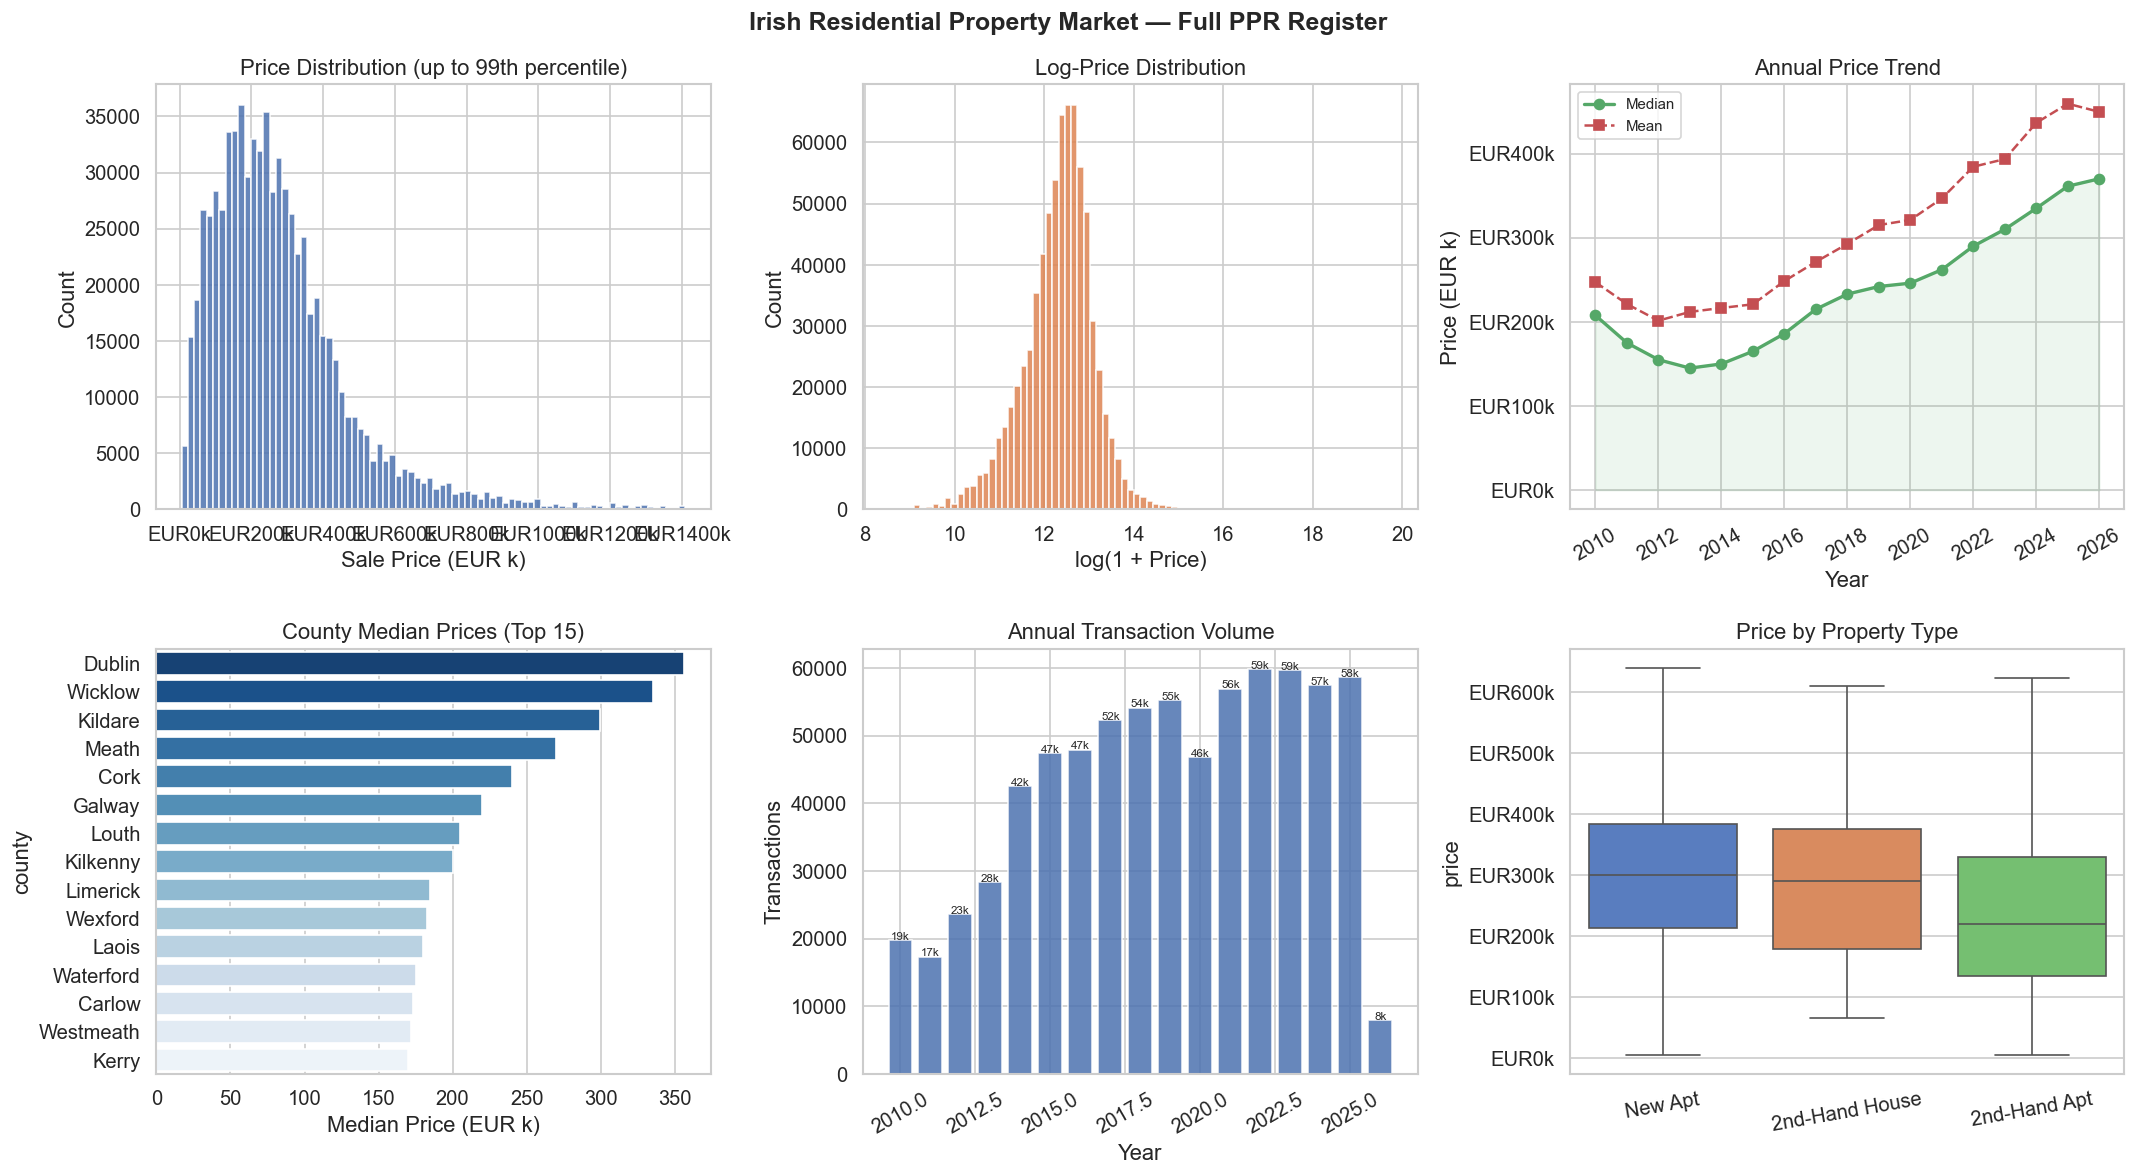

Saved: eda_overview.png


In [15]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Irish Residential Property Market — Full PPR Register', fontsize=15, fontweight='bold')

clip99 = df['price'].quantile(0.99)

ax = axes[0, 0]
ax.hist(df[df['price'] <= clip99]['price'] / 1e3, bins=80, color='#4C72B0', edgecolor='white', alpha=0.85)
ax.set_xlabel('Sale Price (EUR k)')
ax.set_ylabel('Count')
ax.set_title('Price Distribution (up to 99th percentile)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'EUR{x:.0f}k'))

ax = axes[0, 1]
ax.hist(df['log_price'], bins=80, color='#DD8452', edgecolor='white', alpha=0.85)
ax.set_xlabel('log(1 + Price)')
ax.set_ylabel('Count')
ax.set_title('Log-Price Distribution')

ax = axes[0, 2]
yr = df.groupby('year')['price'].agg(['median', 'mean']) / 1e3
ax.plot(yr.index, yr['median'], 'o-', color='#55A868', lw=2, label='Median')
ax.plot(yr.index, yr['mean'],   's--', color='#C44E52', lw=1.5, label='Mean')
ax.fill_between(yr.index, yr['median'], alpha=0.1, color='#55A868')
ax.set_xlabel('Year')
ax.set_ylabel('Price (EUR k)')
ax.set_title('Annual Price Trend')
ax.legend(fontsize=9)
ax.tick_params(axis='x', rotation=30)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'EUR{x:.0f}k'))

ax = axes[1, 0]
top_c = df.groupby('county')['price'].median().sort_values(ascending=False).head(15) / 1e3
sns.barplot(x=top_c.values, y=top_c.index, ax=ax, palette='Blues_r', orient='h')
ax.set_xlabel('Median Price (EUR k)')
ax.set_title('County Median Prices (Top 15)')

ax = axes[1, 1]
vol  = df.groupby('year').size()
bars = ax.bar(vol.index, vol.values, color='#4C72B0', alpha=0.85, edgecolor='white')
ax.set_xlabel('Year')
ax.set_ylabel('Transactions')
ax.set_title('Annual Transaction Volume')
for bar, v in zip(bars, vol.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 100,
            f'{v // 1000:.0f}k', ha='center', fontsize=7)
ax.tick_params(axis='x', rotation=30)

ax = axes[1, 2]
df['_type'] = df['is_new'].map({1: 'New', 0: '2nd-Hand'}) + ' ' + df['is_apartment'].map({1: 'Apt', 0: 'House'})
order_ = df.groupby('_type')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=df[df['price'] <= df['price'].quantile(0.95)],
            x='_type', y='price', order=order_, ax=ax, palette='muted', showfliers=False)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'EUR{x / 1e3:.0f}k'))
ax.set_xlabel('')
ax.set_title('Price by Property Type')
ax.tick_params(axis='x', rotation=10)
df.drop(columns=['_type'], inplace=True, errors='ignore')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'eda_overview.png'), bbox_inches='tight')
plt.show()
print('Saved: eda_overview.png')


## 2.16 Market Trends and Macroeconomic Context

This figure puts property prices in their macroeconomic context. The dual-axis chart of price versus CPI shows how house price inflation diverged from general consumer inflation after 2013. The unemployment chart illustrates the dramatic decline from nearly 18% in 2010 to under 5% by 2024 — the single largest driver of housing demand recovery. The seasonal panel confirms that prices are consistently higher in spring and summer.

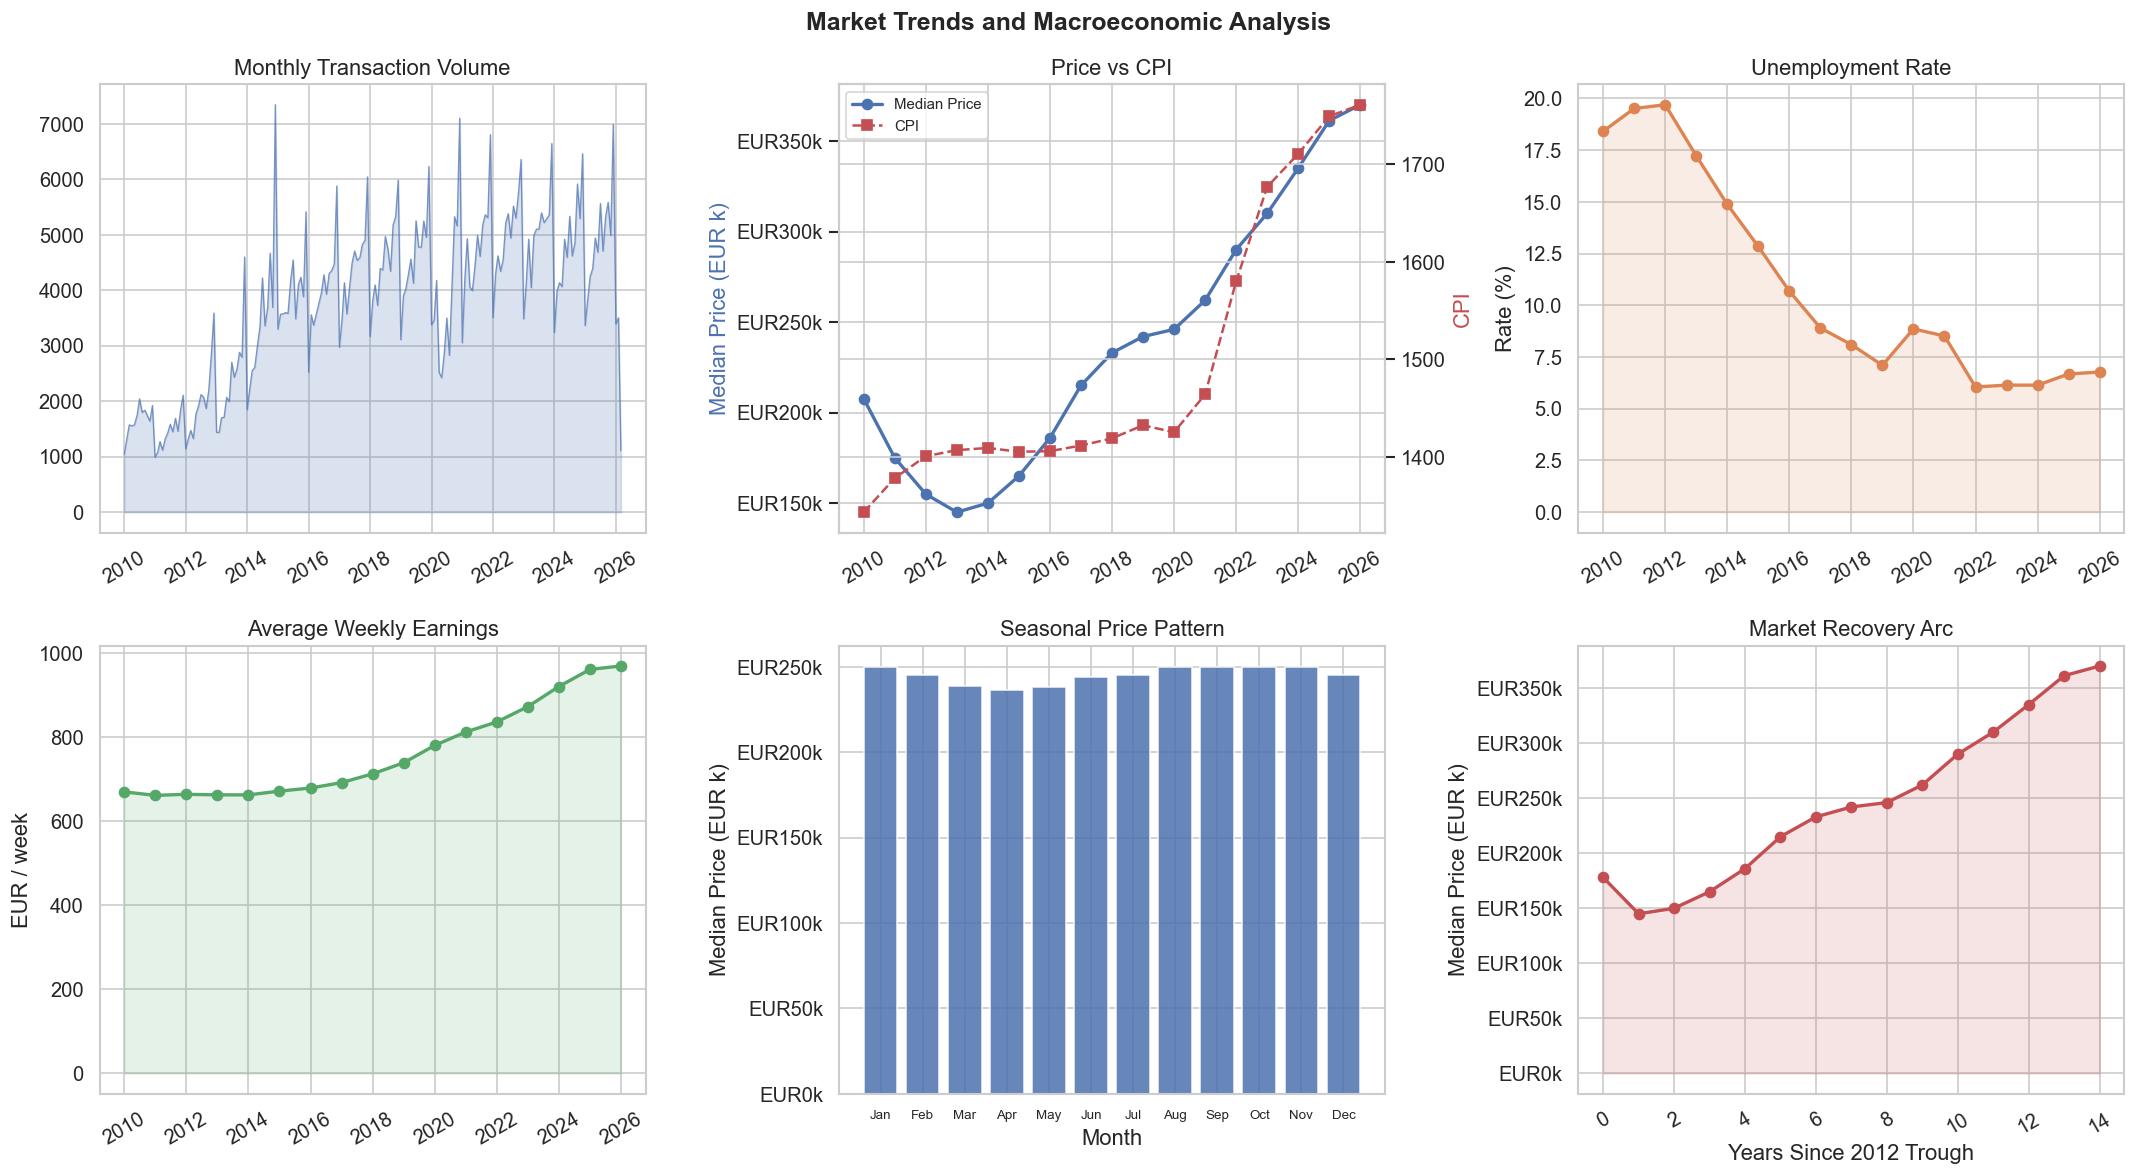

Saved: eda_trends.png


In [16]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Market Trends and Macroeconomic Analysis', fontsize=15, fontweight='bold')

ax = axes[0, 0]
mv = df.groupby(['year', 'month']).size().reset_index(name='n')
mv['dt'] = pd.to_datetime(mv['year'].astype(str) + '-' + mv['month'].astype(str) + '-01')
ax.plot(mv['dt'], mv['n'], color='#4C72B0', lw=0.8, alpha=0.7)
ax.fill_between(mv['dt'], mv['n'], alpha=0.2, color='#4C72B0')
ax.set_title('Monthly Transaction Volume')
ax.tick_params(axis='x', rotation=30)

ax = axes[0, 1]
ax2 = ax.twinx()
my = df.groupby('year').agg(med=('price', 'median'), cpi=('cpi', 'mean')).reset_index()
ax.plot(my['year'], my['med'] / 1e3, 'o-', color='#4C72B0', lw=2, label='Median Price')
ax2.plot(my['year'], my['cpi'], 's--', color='#C44E52', lw=1.5, label='CPI')
ax.set_ylabel('Median Price (EUR k)', color='#4C72B0')
ax2.set_ylabel('CPI', color='#C44E52')
ax.set_title('Price vs CPI')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'EUR{x:.0f}k'))
l1, lb1 = ax.get_legend_handles_labels()
l2, lb2 = ax2.get_legend_handles_labels()
ax.legend(l1 + l2, lb1 + lb2, fontsize=9)
ax.tick_params(axis='x', rotation=30)

ax = axes[0, 2]
uy = df.groupby('year')['unemployment_rate'].mean()
ax.plot(uy.index, uy.values, 'o-', color='#DD8452', lw=2)
ax.fill_between(uy.index, uy.values, alpha=0.15, color='#DD8452')
ax.set_ylabel('Rate (%)')
ax.set_title('Unemployment Rate')
ax.tick_params(axis='x', rotation=30)

ax = axes[1, 0]
ey = df.groupby('year')['avg_weekly_earnings'].mean()
ax.plot(ey.index, ey.values, 'o-', color='#55A868', lw=2)
ax.fill_between(ey.index, ey.values, alpha=0.15, color='#55A868')
ax.set_ylabel('EUR / week')
ax.set_title('Average Weekly Earnings')
ax.tick_params(axis='x', rotation=30)

ax = axes[1, 1]
sm = df.groupby('month')['price'].median() / 1e3
ax.bar(range(1, 13), sm.values, color='#4C72B0', alpha=0.85, edgecolor='white')
ax.set_xlabel('Month')
ax.set_ylabel('Median Price (EUR k)')
ax.set_title('Seasonal Price Pattern')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'EUR{x:.0f}k'))

ax = axes[1, 2]
tr = df.groupby('years_since_trough')['price'].median() / 1e3
ax.plot(tr.index, tr.values, 'o-', color='#C44E52', lw=2)
ax.fill_between(tr.index, tr.values, alpha=0.15, color='#C44E52')
ax.set_xlabel('Years Since 2012 Trough')
ax.set_ylabel('Median Price (EUR k)')
ax.set_title('Market Recovery Arc')
ax.tick_params(axis='x', rotation=30)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'EUR{x:.0f}k'))

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'eda_trends.png'), bbox_inches='tight')
plt.show()
print('Saved: eda_trends.png')


## 2.17 Correlation Heatmap

A correlation heatmap shows pairwise relationships between all key features and the log-price target. The location encodings (`loc_score`, `yr_city_enc`, `city_enc`) show the highest correlations with log-price, confirming that location is the dominant determinant of property value. Unemployment shows a strong negative correlation — prices fell when unemployment was high and rose as it recovered.

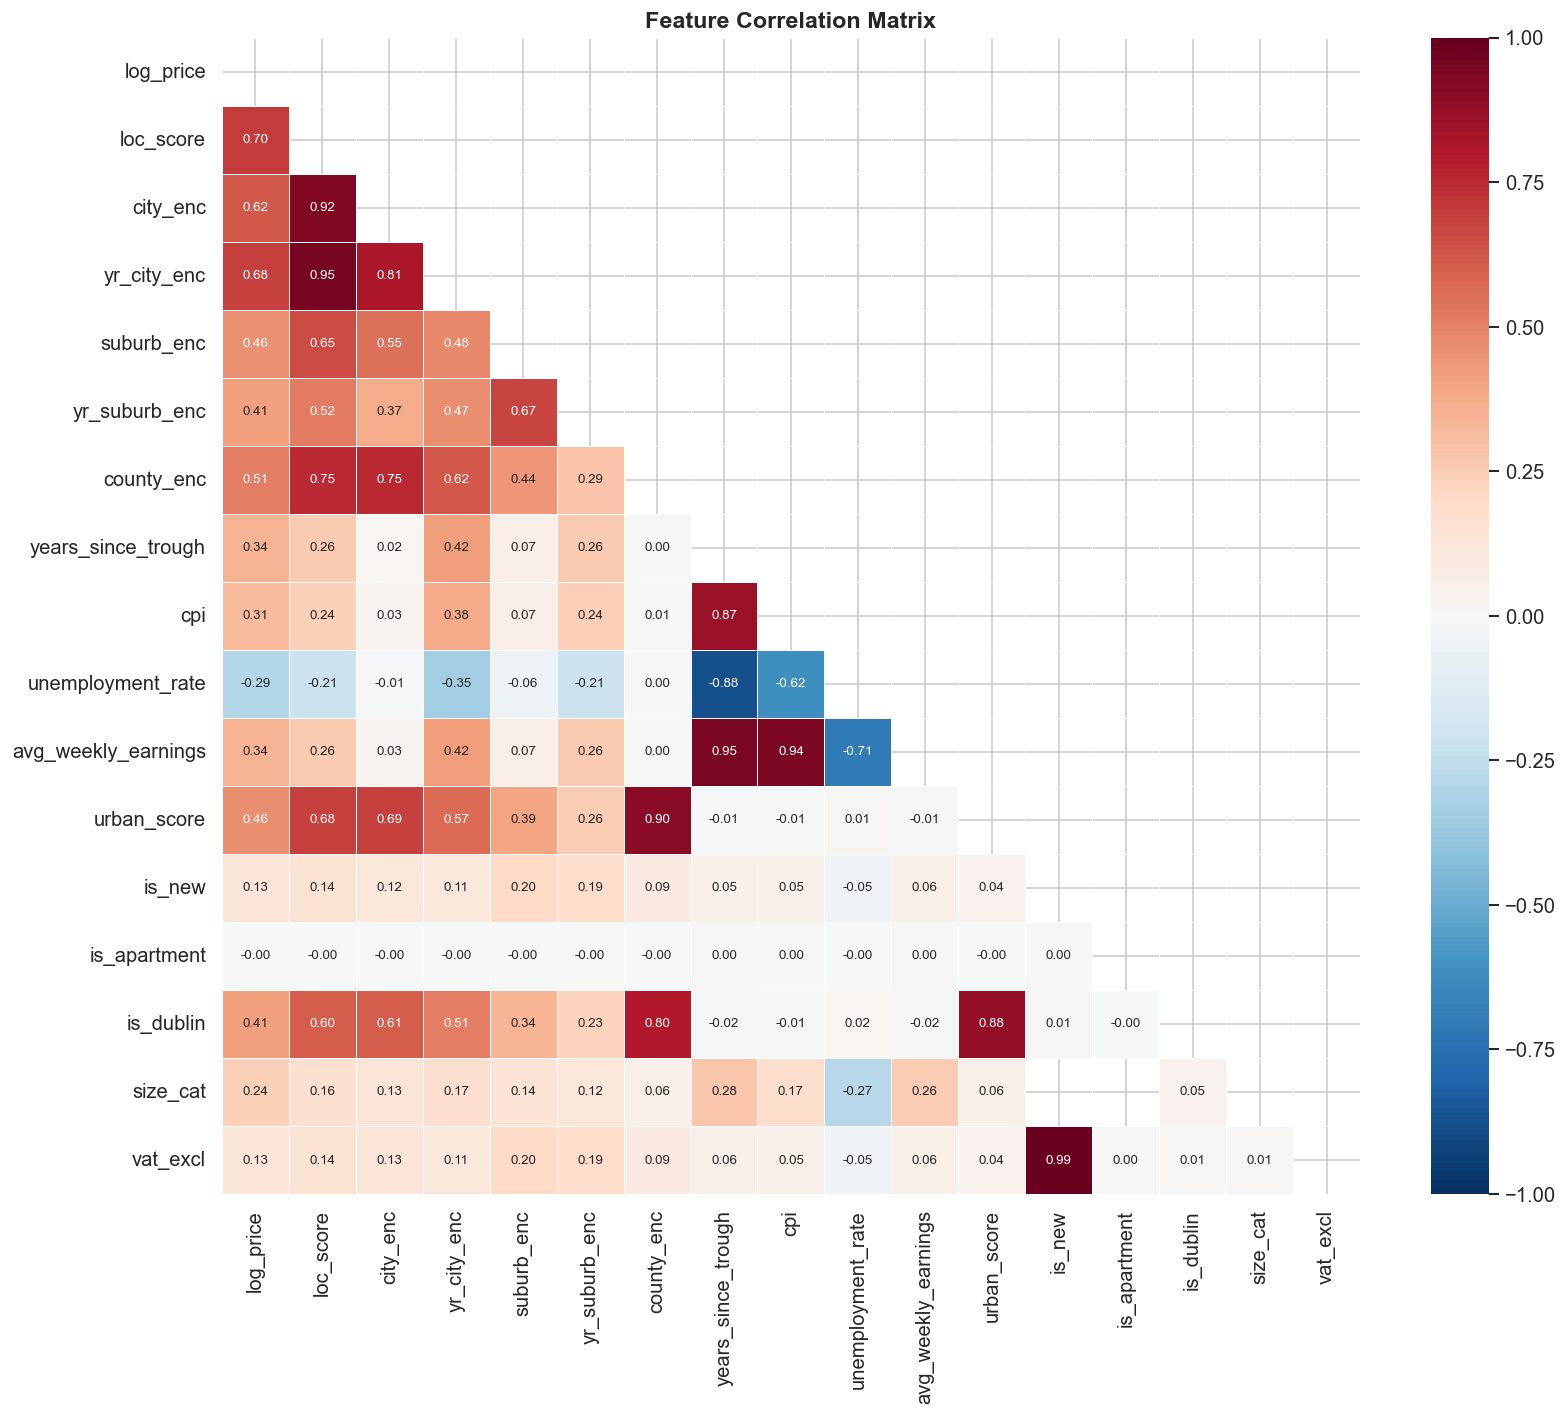

Saved: eda_correlation.png


In [17]:
key_cols = [
    'log_price', 'loc_score', 'city_enc', 'yr_city_enc',
    'suburb_enc', 'yr_suburb_enc', 'county_enc',
    'years_since_trough', 'cpi', 'unemployment_rate',
    'avg_weekly_earnings', 'urban_score',
    'is_new', 'is_apartment', 'is_dublin', 'size_cat', 'vat_excl'
]
key_cols = [c for c in key_cols if c in df.columns]
corr = df[key_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            ax=ax, linewidths=0.4, annot_kws={'size': 8})
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'eda_correlation.png'), bbox_inches='tight')
plt.show()
print('Saved: eda_correlation.png')


## 2.18 Encoding Quality Check

These scatter plots show how well each location encoding tracks the log-price. A tight positive linear relationship — indicated by a high Pearson r — confirms that the OOF encoding is capturing genuine price signal rather than noise. The year-city encoding typically shows the strongest correlation because it reflects both where a property is and when it was sold.

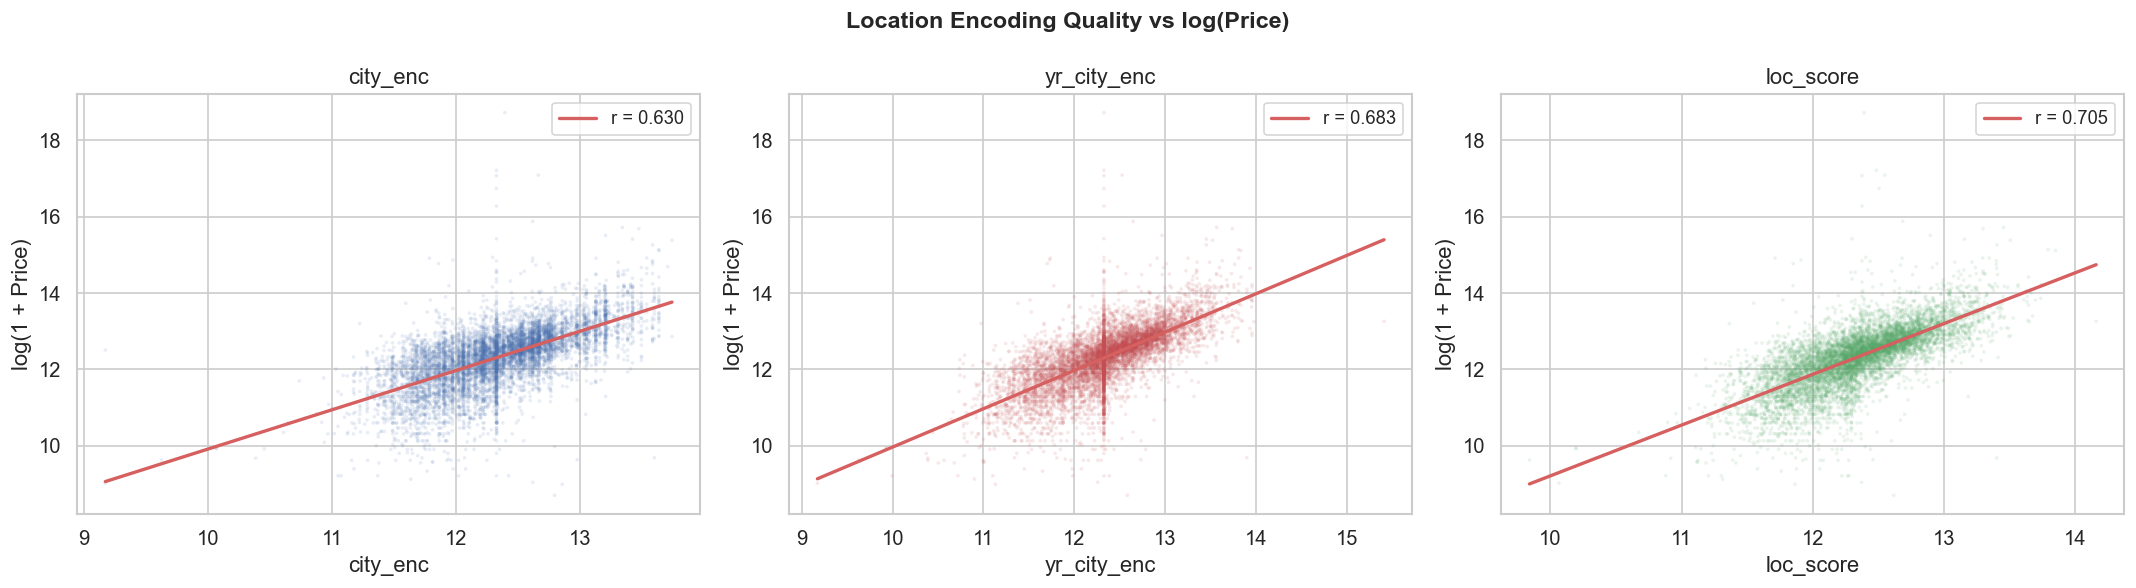

Saved: eda_encoding_quality.png


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Location Encoding Quality vs log(Price)', fontsize=14, fontweight='bold')

sample = df.sample(min(8000, len(df)), random_state=RANDOM_STATE)

for ax, (col, color) in zip(axes, [
    ('city_enc',    '#4C72B0'),
    ('yr_city_enc', '#C44E52'),
    ('loc_score',   '#55A868'),
]):
    if col not in df.columns:
        continue
    ax.scatter(sample[col], sample['log_price'],
               alpha=0.12, s=5, color=color, edgecolors='none')
    x_vals = sample[col].fillna(sample[col].median())
    z = np.polyfit(x_vals, sample['log_price'], 1)
    x_line = np.linspace(sample[col].min(), sample[col].max(), 100)
    ax.plot(x_line, np.poly1d(z)(x_line), 'r-', linewidth=2,
            label=f'r = {sample[col].corr(sample["log_price"]):.3f}')
    ax.set_xlabel(col)
    ax.set_ylabel('log(1 + Price)')
    ax.set_title(col)
    ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'eda_encoding_quality.png'), bbox_inches='tight')
plt.show()
print('Saved: eda_encoding_quality.png')


## 2.19 Outlier Summary and Price Statistics

The IQR method identifies statistical outliers. The resulting bounds and the full price distribution summary table are printed here. Outliers are not removed at this stage — they are handled during model preparation in Section 3 through winsorisation at the 1st and 99th percentiles.

In [19]:
Q1  = df['price'].quantile(0.25)
Q3  = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers    = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]

print(f'Q1 (25th):     EUR {Q1:>12,.0f}')
print(f'Q3 (75th):     EUR {Q3:>12,.0f}')
print(f'IQR:           EUR {IQR:>12,.0f}')
print(f'Lower bound:   EUR {lower_bound:>12,.0f}')
print(f'Upper bound:   EUR {upper_bound:>12,.0f}')
print(f'Outliers:      {len(outliers):>8,} rows ({100 * len(outliers) / len(df):.1f}%)')
print()
display(df['price'].describe().rename('price (EUR)').to_frame())

print(f'\nDataset ready for Section 3.')
print(f'Final shape: {df.shape[0]:,} rows x {df.shape[1]} columns')


Q1 (25th):     EUR      148,000
Q3 (75th):     EUR      365,000
IQR:           EUR      217,000
Lower bound:   EUR     -177,500
Upper bound:   EUR      690,500
Outliers:        38,309 rows (5.2%)



,price (EUR)
count,7.360020e+05
mean,3.198028e+05
std,1.151949e+06
min,5.030530e+03
25%,1.480000e+05
50%,2.450000e+05
75%,3.650000e+05
max,3.876652e+08



Dataset ready for Section 3.
Final shape: 736,002 rows x 78 columns


## Export Dataset for Section 3

The fully engineered dataset is saved at the end of this section. Section 3 loads this file directly so it does not need to repeat any of the feature engineering steps. The file includes all engineered columns: OOF location encodings, the composite location score, macro lag features, interaction terms, rolling momentum columns, and the log-price target.

In [21]:
OUTPUT_PATH_S2 = os.path.join(os.getcwd(), 'section_2_output.csv')

# All engineered feature columns plus the target and raw price
export_cols_s2 = [
    # Identifiers and target
    'sale_date', 'county', 'price', 'log_price',
    # Structural
    'is_new', 'is_apartment', 'vat_excl', 'size_cat', 'is_dublin',
    # Temporal
    'year', 'month', 'quarter', 'month_sin', 'month_cos',
    'quarter_sin', 'quarter_cos', 'years_since_trough', 'year_sq', 'time_idx',
    # County geo-proxies
    'urban_score', 'transport_score', 'amenity_score',
    'county_ref_logprice', 'county_n_sales',
    # OOF location encodings
    'county_enc', 'city_enc', 'suburb_enc', 'dublin_pc_enc',
    'yr_city_enc', 'yr_suburb_enc', 'qtr_city_enc',
    'type_city_enc', 'apt_city_enc', 'dp_type_enc',
    # Composite score
    'loc_score',
    # Macro
    'cpi', 'unemployment_rate', 'avg_weekly_earnings',
    'cpi_lag1', 'cpi_lag3', 'cpi_lag6',
    'unemployment_rate_lag1', 'unemployment_rate_lag3', 'unemployment_rate_lag6',
    'avg_weekly_earnings_lag1', 'avg_weekly_earnings_lag3', 'avg_weekly_earnings_lag6',
    'cpi_yoy', 'unemp_change_6m', 'earn_change_6m',
    # Interactions
    'new_x_dublin', 'apt_x_dublin', 'size_x_urban', 'vat_x_new',
    'loc_x_recovery', 'loc_x_new', 'loc_x_apt',
    'unemp_x_loc', 'earn_x_loc', 'time_x_loc',
    # Rolling momentum
    'city_roll_90d', 'city_roll_6m', 'city_roll_1y', 'county_roll_1y',
]

export_cols_s2 = [c for c in export_cols_s2 if c in df.columns]

df[export_cols_s2].to_csv(OUTPUT_PATH_S2, index=False)

print(f'Dataset exported to: {OUTPUT_PATH_S2}')
print(f'Rows:    {len(df):,}')
print(f'Columns: {len(export_cols_s2)}')
print()
print('Columns exported:')
for col in export_cols_s2:
    print(f'  {col}')
print()
print('This file is the input for Section 3.')


Dataset exported to: /Users/mac/Desktop/Ireland Housing Price Prediction Project/files/section_2_output.csv
Rows:    736,002
Columns: 64

Columns exported:
  sale_date
  county
  price
  log_price
  is_new
  is_apartment
  vat_excl
  size_cat
  is_dublin
  year
  month
  quarter
  month_sin
  month_cos
  quarter_sin
  quarter_cos
  years_since_trough
  year_sq
  time_idx
  urban_score
  transport_score
  amenity_score
  county_ref_logprice
  county_n_sales
  county_enc
  city_enc
  suburb_enc
  dublin_pc_enc
  yr_city_enc
  yr_suburb_enc
  qtr_city_enc
  type_city_enc
  apt_city_enc
  dp_type_enc
  loc_score
  cpi
  unemployment_rate
  avg_weekly_earnings
  cpi_lag1
  cpi_lag3
  cpi_lag6
  unemployment_rate_lag1
  unemployment_rate_lag3
  unemployment_rate_lag6
  avg_weekly_earnings_lag1
  avg_weekly_earnings_lag3
  avg_weekly_earnings_lag6
  cpi_yoy
  unemp_change_6m
  earn_change_6m
  new_x_dublin
  apt_x_dublin
  size_x_urban
  vat_x_new
  loc_x_recovery
  loc_x_new
  loc_x_apt
  un